In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path

In [2]:
#Pre processing registration data

DATA_DIR = Path("AircraftRegistrationData")

master = pd.read_csv(DATA_DIR / "MASTER.txt", dtype=str, low_memory=False)
acftref = pd.read_csv(DATA_DIR / "ACFTREF.txt", dtype=str, low_memory=False)

master_sub = master[["N-NUMBER", "MFR MDL CODE", "YEAR MFR"]].rename(
    columns={
        "N-NUMBER": "N_NUMBER",
        "MFR MDL CODE": "MFR_MDL_CODE",
        "YEAR MFR": "YEAR_MANUFACTURED"
    }
)

acftref_sub = acftref[["CODE", "MFR", "MODEL", "NO-SEATS"]].rename(
    columns={
        "CODE": "MFR_MDL_CODE",
        "NO-SEATS": "NUM_SEATS"
    }
)

aircraft = master_sub.merge(acftref_sub, on="MFR_MDL_CODE", how="left")

aircraft["N_NUMBER"] = (
    aircraft["N_NUMBER"]
    .astype(str)
    .str.strip()
    .str.upper()
    .apply(lambda x: "N" + x if not x.startswith("N") else x)
)

aircraft = aircraft[[
    "N_NUMBER",
    "MFR",
    "MODEL",
    "NUM_SEATS",
    "YEAR_MANUFACTURED"
]]

print("Aircraft sample:")
print(aircraft.head())

Aircraft sample:
  N_NUMBER                             MFR                 MODEL NUM_SEATS  \
0     N100  PIPER                           J3C-65                     002   
1   N10000  CIRRUS DESIGN CORP              SR22T                      005   
2   N10001  WACO                            ASO                        003   
3   N10004  CESSNA                          T182T                      004   
4   N10006  BEECH                           D-45 (T-34B)               004   

  YEAR_MANUFACTURED  
0              1940  
1                    
2              1928  
3                    
4              1955  


In [3]:
#Importing flights

data_dir = Path("DelayData")
flight_files = sorted(data_dir.glob("*.csv"))

print("\nFound flight files:")
for f in flight_files:
    print(" -", f.name)

flight_dfs = []
for f in flight_files:
    df = pd.read_csv(f)

    # Normalize carrier column
    if "OP_UNIQUE_CARRIER" not in df.columns and "MKT_UNIQUE_CARRIER" in df.columns:
        df = df.rename(columns={"MKT_UNIQUE_CARRIER": "OP_UNIQUE_CARRIER"})

    df["ORIGIN_AIRPORT_ID"] = pd.to_numeric(df["ORIGIN_AIRPORT_ID"], errors="coerce")
    flight_dfs.append(df)

flights = pd.concat(flight_dfs, ignore_index=True)
print("\nUnified flights:", flights.shape)


Found flight files:
 - apr23.csv
 - apr24.csv
 - aug23.csv
 - aug24.csv
 - dec23.csv
 - dec24.csv
 - feb23.csv
 - feb24.csv
 - jan23.csv
 - jan24.csv
 - jul23.csv
 - jul24.csv
 - jun23.csv
 - jun24.csv
 - mar23.csv
 - mar24.csv
 - may23.csv
 - may24.csv
 - nov23.csv
 - nov24.csv
 - oct23.csv
 - oct24.csv
 - sep23.csv
 - sep24.csv

Unified flights: (2586073, 10)


In [4]:
#Filtering for bay area

AIRPORT_IDS = {
    "OAK": 13796,
    "SFO": 14771,
    "SJC": 14831
}

flights = flights[flights["ORIGIN_AIRPORT_ID"].isin(AIRPORT_IDS.values())].copy()
print("After Bay Area filter:", flights.shape)

After Bay Area filter: (468662, 10)


In [5]:
#Importing weather

weather_file = Path("WeatherData") / "weather.csv"

weather = pd.read_csv(weather_file, skiprows=5)
weather["time"] = pd.to_datetime(weather["time"])
weather["time_hour"] = weather["time"].dt.floor("H")

print("\nWeather sample:")
print(weather.head())

# Map airports → weather locations
airport_to_loc = {14771:0, 13796:1, 14831:2}
flights["location_id"] = flights["ORIGIN_AIRPORT_ID"].astype(int).map(airport_to_loc)


Weather sample:
   location_id                time  temperature_2m (°F)  cloud_cover_low (%)  \
0            0 2023-01-01 00:00:00                 51.2                    0   
1            0 2023-01-01 01:00:00                 51.0                    0   
2            0 2023-01-01 02:00:00                 50.4                    0   
3            0 2023-01-01 03:00:00                 49.9                    0   
4            0 2023-01-01 04:00:00                 50.2                    0   

   precipitation (inch)  wind_speed_10m (mp/h)  wind_speed_100m (mp/h)  \
0                   0.0                   13.7                    21.6   
1                   0.0                   14.5                    21.6   
2                   0.0                   10.8                    18.7   
3                   0.0                    6.4                    14.0   
4                   0.0                   13.2                    19.0   

   wind_direction_10m (°)  wind_direction_100m (°)  wind_

In [6]:
#Prep for mapping weather to flights

dep_str = (
    flights["CRS_DEP_TIME"]
    .fillna(0)
    .astype(int)
    .astype(str)
    .str.zfill(4)
)

dep_date = pd.to_datetime({
    "year": flights["YEAR"].astype(int),
    "month": flights["MONTH"].astype(int),
    "day": flights["DAY_OF_MONTH"].astype(int)
})

flights["DEP_HOUR"] = (
    dep_date
    + pd.to_timedelta(dep_str.str[:2].astype(int), unit="h")
    + pd.to_timedelta(dep_str.str[2:].astype(int), unit="m")
).dt.floor("H")

df.head()

,YEAR,MONTH,DAY_OF_MONTH,DAY_OF_WEEK,OP_UNIQUE_CARRIER,TAIL_NUM,ORIGIN_AIRPORT_ID,DEST_AIRPORT_ID,CRS_DEP_TIME,DEP_DELAY_NEW
0,2024,9,1,7,AA,N101NN,12478,12892,1625,0.0
1,2024,9,1,7,AA,N101NN,12892,12478,2120,7.0
2,2024,9,1,7,AA,N101NN,14771,12478,620,0.0
3,2024,9,1,7,AA,N102NN,12478,12892,1100,0.0
4,2024,9,1,7,AA,N102NN,12892,10721,1510,0.0


In [7]:
#Mapping weather to flights and data clean

df = flights.merge(
    weather,
    left_on=["location_id", "DEP_HOUR"],
    right_on=["location_id", "time_hour"],
    how="left"
)

# Clean column names
df = df.rename(columns={
    "temperature_2m (°F)": "temp_f",
    "cloud_cover_low (%)": "cloud_cover_low_pct",
    "precipitation (inch)": "precip_in",
    "wind_speed_10m (mp/h)": "wind_speed_10m_mph",
    "wind_speed_100m (mp/h)": "wind_speed_100m_mph",
    "wind_gusts_10m (mp/h)": "wind_gust_10m_mph",
    "is_day ()": "is_day"
})

cols_to_drop = [
    "time_hour", 
    "time",
    "wind_speed_10m_mph",
    "wind_dir_10m_deg",
    "wind_dir_100m_deg",
    "DEP_HOUR",
    "DEST_AIRPORT_ID"
]

df = df.drop(columns=[c for c in cols_to_drop if c in df.columns])


print("After weather merge:", df.shape)
print(df.head())

After weather merge: (468662, 18)
   YEAR  MONTH  DAY_OF_MONTH  DAY_OF_WEEK OP_UNIQUE_CARRIER TAIL_NUM  \
0  2023      4             1            6                AA   N103NN   
1  2023      4             1            6                AA   N108NN   
2  2023      4             1            6                AA   N112AN   
3  2023      4             1            6                AA   N121AN   
4  2023      4             1            6                AA   N122NN   

   ORIGIN_AIRPORT_ID  CRS_DEP_TIME  DEP_DELAY_NEW  location_id  temp_f  \
0              14771          1045            0.0            0    51.4   
1              14771          2225            0.0            0    50.3   
2              14771           600            0.0            0    47.0   
3              14771          1332           73.0            0    54.3   
4              14771           600            0.0            0    47.0   

   cloud_cover_low_pct  precip_in  wind_speed_100m_mph  \
0                    0        

In [8]:
#Mapping aircraft tail num info

df["N_NUMBER"] = (
    df["TAIL_NUM"]
    .astype(str)
    .str.strip()
    .str.upper()
    .apply(lambda x: "N" + x if not x.startswith("N") else x)
)

df = df.merge(aircraft, on="N_NUMBER", how="left")

df = df.rename(columns={
    "MFR": "aircraft_mfr",
    "MODEL": "aircraft_model",
    "NUM_SEATS": "aircraft_num_seats",
    "YEAR_MANUFACTURED": "aircraft_year_mfr"
})

df = df.drop(columns=["N_NUMBER"])

In [9]:
#Fixing manufacturer dupes

manufacturer_fix = {
    # --- AIRBUS variants ---
    "AIRBUS": "AIRBUS",
    "AIRBUS INDUSTRIE": "AIRBUS",
    "AIRBUS SAS": "AIRBUS",
    "AIRBUS S A S": "AIRBUS",
    "AIRBUS CANADA LTD PTNRSP": "AIRBUS",
    "AIRBUS CANADA LP": "AIRBUS",

    # --- BOEING ---
    "BOEING": "BOEING",

    # --- EMBRAER variants ---
    "EMBRAER": "EMBRAER",
    "EMBRAER S A": "EMBRAER",
    "EMBRAER-EMPRESA BRASILEIRA DE": "EMBRAER",
    "YABORA INDUSTRIA AERONAUTICA S": "EMBRAER",

    # --- BOMBARDIER ---
    "BOMBARDIER INC": "BOMBARDIER",
    "C SERIES AIRCRAFT LTD PTNRSP": "BOMBARDIER",
}

df["aircraft_mfr"] = (
    df["aircraft_mfr"]
    .astype(str)
    .str.strip()
    .replace(manufacturer_fix)
)


In [10]:
#Single aircraft that has data hole for some reason
df["aircraft_mfr"] = df["aircraft_mfr"].replace("nan", "BOMBARDIER")

In [11]:
df = df.dropna(subset=["DEP_DELAY_NEW", "TAIL_NUM"])

In [12]:
# Aircraft registration cleaning and imputation

df["aircraft_model"] = df["aircraft_model"].replace(r"^\s*$", np.nan, regex=True)
df["aircraft_num_seats"] = df["aircraft_num_seats"].replace(r"^\s*$", np.nan, regex=True)
df["aircraft_year_mfr"] = df["aircraft_year_mfr"].replace(r"^\s*$", np.nan, regex=True)

df["aircraft_num_seats"] = pd.to_numeric(df["aircraft_num_seats"], errors="coerce")
df["aircraft_year_mfr"] = pd.to_numeric(df["aircraft_year_mfr"], errors="coerce")

print("Missing before:")
print(df[["aircraft_model","aircraft_num_seats","aircraft_year_mfr"]].isna().sum())


df["aircraft_model"] = df["aircraft_model"].fillna(
    df.groupby(["OP_UNIQUE_CARRIER", "aircraft_num_seats", "aircraft_year_mfr"])["aircraft_model"]
      .transform(lambda s: s.mode().iloc[0] if not s.mode().empty else np.nan)
)


df["aircraft_model"] = df["aircraft_model"].fillna(
    df.groupby("OP_UNIQUE_CARRIER")["aircraft_model"]
      .transform(lambda s: s.mode().iloc[0] if not s.mode().empty else np.nan)
)

for col in ["aircraft_num_seats", "aircraft_year_mfr"]:
    df[col] = df[col].fillna(
        df.groupby("OP_UNIQUE_CARRIER")[col]
          .transform(lambda s: s.mode().iloc[0] if not s.mode().empty else np.nan)
    )

df["aircraft_num_seats"].fillna(df["aircraft_num_seats"].median(), inplace=True)
df["aircraft_year_mfr"].fillna(df["aircraft_year_mfr"].median(), inplace=True)
df["aircraft_model"].fillna(df["aircraft_model"].mode().iloc[0], inplace=True)

Missing before:
aircraft_model        18532
aircraft_num_seats    18532
aircraft_year_mfr     24803
dtype: int64


In [13]:
#Target column, day of year col

df["DELAYED"] = (df["DEP_DELAY_NEW"] > 15).astype(int)

df["aircraft_num_seats"] = pd.to_numeric(df["aircraft_num_seats"], errors="coerce")
df["aircraft_year_mfr"] = pd.to_numeric(df["aircraft_year_mfr"], errors="coerce")

df["DAY_OF_YEAR"] = pd.to_datetime(
    df["YEAR"].astype(int).astype(str) + "-" +
    df["MONTH"].astype(int).astype(str) + "-" +
    df["DAY_OF_MONTH"].astype(int).astype(str),
    errors="coerce"
).dt.dayofyear

In [14]:
print(df["aircraft_mfr"].dropna().unique())

['AIRBUS' 'BOEING' 'EMBRAER' 'BOMBARDIER']


In [15]:
#Carrier lookup

carriers = pd.read_csv("carriers.csv")

df = df.merge(
    carriers,
    left_on="OP_UNIQUE_CARRIER",
    right_on="Code",
    how="left"
)

df = df.rename(columns={"Description": "CARRIER_NAME"})
df = df.drop(columns=["Code"])


In [16]:
id_to_airport = {14771:"SFO", 13796:"OAK", 14831:"SJC"}
df["airport"] = df["ORIGIN_AIRPORT_ID"].map(id_to_airport)

df = df.drop(columns=["ORIGIN_AIRPORT_ID"])


print("\nFinal dataset shape:", df.shape)
print(df.head())


Final dataset shape: (464050, 25)
   YEAR  MONTH  DAY_OF_MONTH  DAY_OF_WEEK OP_UNIQUE_CARRIER TAIL_NUM  \
0  2023      4             1            6                AA   N103NN   
1  2023      4             1            6                AA   N108NN   
2  2023      4             1            6                AA   N112AN   
3  2023      4             1            6                AA   N121AN   
4  2023      4             1            6                AA   N122NN   

   CRS_DEP_TIME  DEP_DELAY_NEW  location_id  temp_f  ...  wind_gust_10m_mph  \
0          1045            0.0            0    51.4  ...                4.9   
1          2225            0.0            0    50.3  ...                9.6   
2           600            0.0            0    47.0  ...                7.6   
3          1332           73.0            0    54.3  ...                7.2   
4           600            0.0            0    47.0  ...                7.6   

   is_day  aircraft_mfr        aircraft_model  aircraft_n

In [18]:
df.corr()

C:\Users\herbe\AppData\Local\Temp\ipykernel_36756\1134722465.py:1: FutureWarning: The default value of numeric_only in DataFrame.corr is deprecated. In a future version, it will default to False. Select only valid columns or specify the value of numeric_only to silence this warning.
  df.corr()


,YEAR,MONTH,DAY_OF_MONTH,DAY_OF_WEEK,CRS_DEP_TIME,DEP_DELAY_NEW,location_id,temp_f,cloud_cover_low_pct,precip_in,wind_speed_100m_mph,wind_direction_10m (°),wind_direction_100m (°),wind_gust_10m_mph,is_day,aircraft_num_seats,aircraft_year_mfr,DELAYED,DAY_OF_YEAR
YEAR,1.000000,0.013950,0.002891,0.007788,-0.022161,1.501897e-02,-0.006477,0.097191,-0.046400,-0.018540,-0.018601,0.002273,-1.484772e-03,-0.039761,0.015362,0.007081,0.041491,0.015421,0.018252
MONTH,0.013950,1.000000,0.010084,0.018347,0.001714,-2.850046e-02,-0.013319,0.324282,-0.025177,-0.073711,-0.175254,0.012791,-1.236608e-02,-0.163619,-0.048444,0.008479,0.009346,-0.045595,0.996408
DAY_OF_MONTH,0.002891,0.010084,1.000000,0.001191,0.000487,8.129592e-03,-0.000497,-0.010491,-0.007676,-0.007698,0.010067,-0.036638,-3.962760e-02,0.008825,-0.007402,-0.000223,0.004256,0.010800,0.094439
DAY_OF_WEEK,0.007788,0.018347,0.001191,1.000000,0.001398,1.782855e-02,-0.012838,-0.007139,0.018175,0.005231,0.012388,-0.013665,-1.420250e-02,0.005401,-0.007769,0.001160,0.003973,0.026837,0.018432
CRS_DEP_TIME,-0.022161,0.001714,0.000487,0.001398,1.000000,8.135004e-02,-0.088034,0.129056,-0.205654,-0.023389,0.303224,0.194459,2.111506e-01,0.272470,-0.422920,-0.041186,-0.026921,0.152917,0.001564
DEP_DELAY_NEW,0.015019,-0.028500,0.008130,0.017829,0.081350,1.000000e+00,-0.056794,0.004131,0.015301,0.039940,0.090312,-0.001577,4.329703e-09,0.078088,-0.013486,0.043879,-0.022520,0.535626,-0.027715
location_id,-0.006477,-0.013319,-0.000497,-0.012838,-0.088034,-5.679419e-02,1.000000,0.200221,-0.050801,0.006599,-0.208004,0.085629,1.151551e-01,-0.078580,0.051831,-0.132228,0.076219,-0.054017,-0.013316
temp_f,0.097191,0.324282,-0.010491,-0.007139,0.129056,4.130673e-03,0.200221,1.000000,-0.221166,-0.111036,0.075341,0.360741,3.202779e-01,0.199566,0.242374,-0.038965,0.005069,0.024300,0.321246
cloud_cover_low_pct,-0.046400,-0.025177,-0.007676,0.018175,-0.205654,1.530099e-02,-0.050801,-0.221166,1.000000,0.202379,0.053602,-0.186059,-1.730025e-01,0.056748,0.005362,0.029016,0.002408,0.002974,-0.026111
precip_in,-0.018540,-0.073711,-0.007698,0.005231,-0.023389,3.993985e-02,0.006599,-0.111036,0.202379,1.000000,0.148320,-0.153402,-1.329064e-01,0.128025,-0.043006,-0.002280,0.002943,0.046070,-0.073772


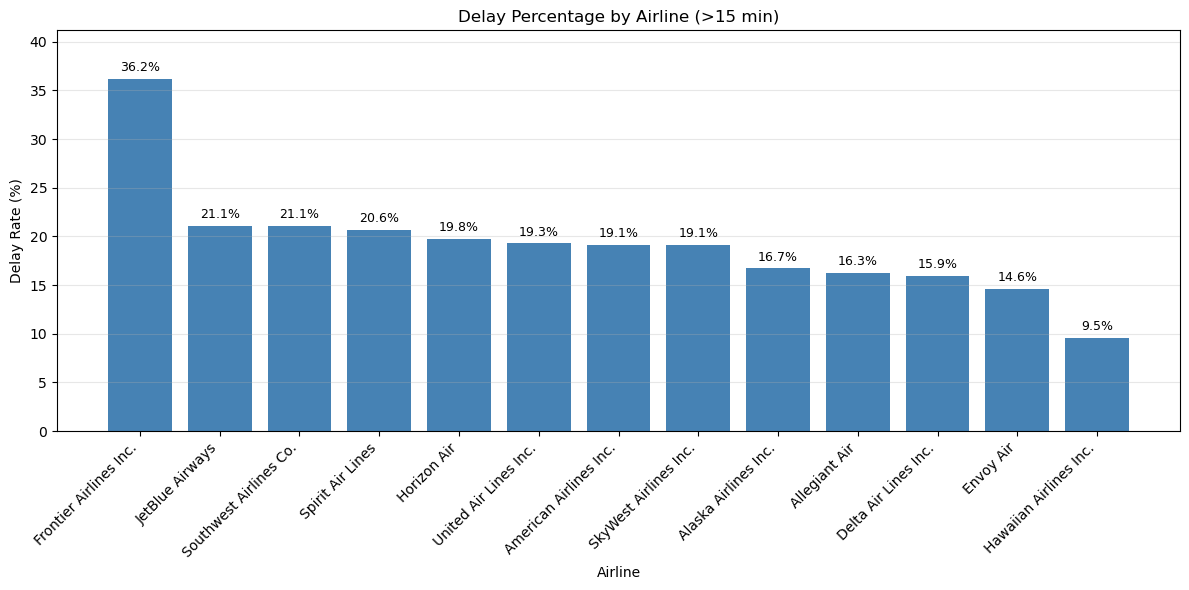

In [19]:
import matplotlib.pyplot as plt

# Compute delay % by airline
delay_by_airline = (
    df.groupby("CARRIER_NAME")["DELAYED"]
      .mean()
      .sort_values(ascending=False) * 100
)

plt.figure(figsize=(12,6))
bars = plt.bar(delay_by_airline.index, delay_by_airline.values, color="steelblue")

# Add labels above bars
for bar in bars:
    y = bar.get_height()
    plt.text(bar.get_x() + bar.get_width()/2, y + 0.5, f"{y:.1f}%", 
             ha='center', va='bottom', fontsize=9)

plt.title("Delay Percentage by Airline (>15 min)")
plt.xlabel("Airline")
plt.ylabel("Delay Rate (%)")
plt.ylim(0, delay_by_airline.max() + 5)
plt.xticks(rotation=45, ha="right")
plt.grid(axis="y", alpha=0.3)
plt.tight_layout()
plt.show()


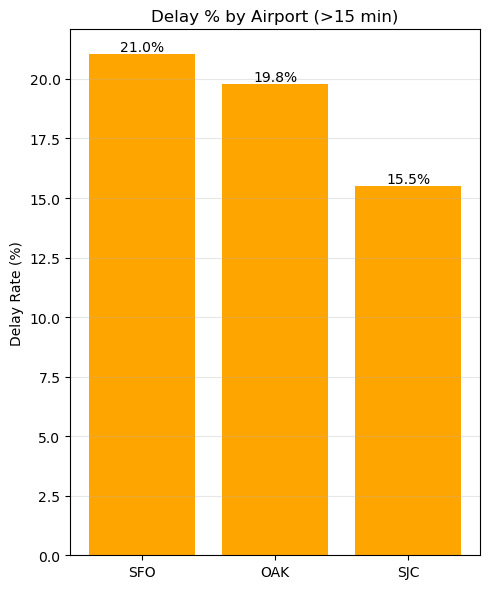

In [20]:
# Compute delay % by airport (SFO/OAK/SJC)
delay_by_airport = (
    df.groupby("airport")["DELAYED"].mean().sort_values(ascending=False) * 100
)

plt.figure(figsize=(5,6))
bars = plt.bar(delay_by_airport.index, delay_by_airport.values, color="orange")
for bar in bars:
    y = bar.get_height()
    plt.text(bar.get_x()+bar.get_width()/2, y, f"{y:.1f}%", 
             ha='center', va='bottom')
plt.title("Delay % by Airport (>15 min)")
plt.ylabel("Delay Rate (%)")
plt.grid(axis="y", alpha=0.3)
plt.tight_layout()
plt.show()


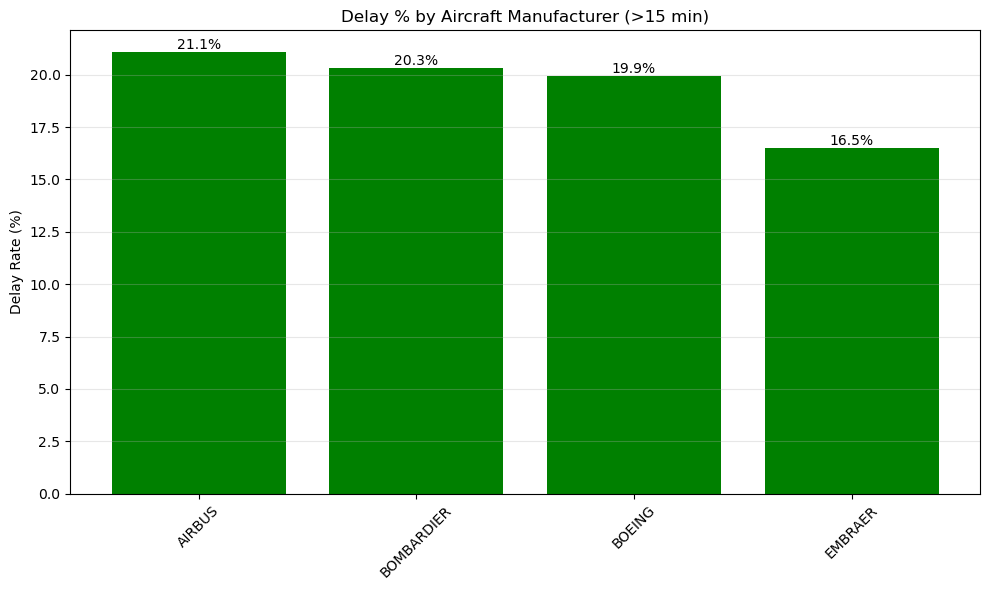

In [28]:
delay_by_mfr = (
    df.groupby("aircraft_mfr")["DELAYED"].mean().sort_values(ascending=False) * 100
)

plt.figure(figsize=(10,6))
bars = plt.bar(delay_by_mfr.index, delay_by_mfr.values, color="green")
for bar in bars:
    y = bar.get_height()
    plt.text(bar.get_x()+bar.get_width()/2, y, f"{y:.1f}%", 
             ha='center', va='bottom')
plt.title("Delay % by Aircraft Manufacturer (>15 min)")
plt.ylabel("Delay Rate (%)")
plt.xticks(rotation=45)
plt.grid(axis="y", alpha=0.3)
plt.tight_layout()
plt.show()

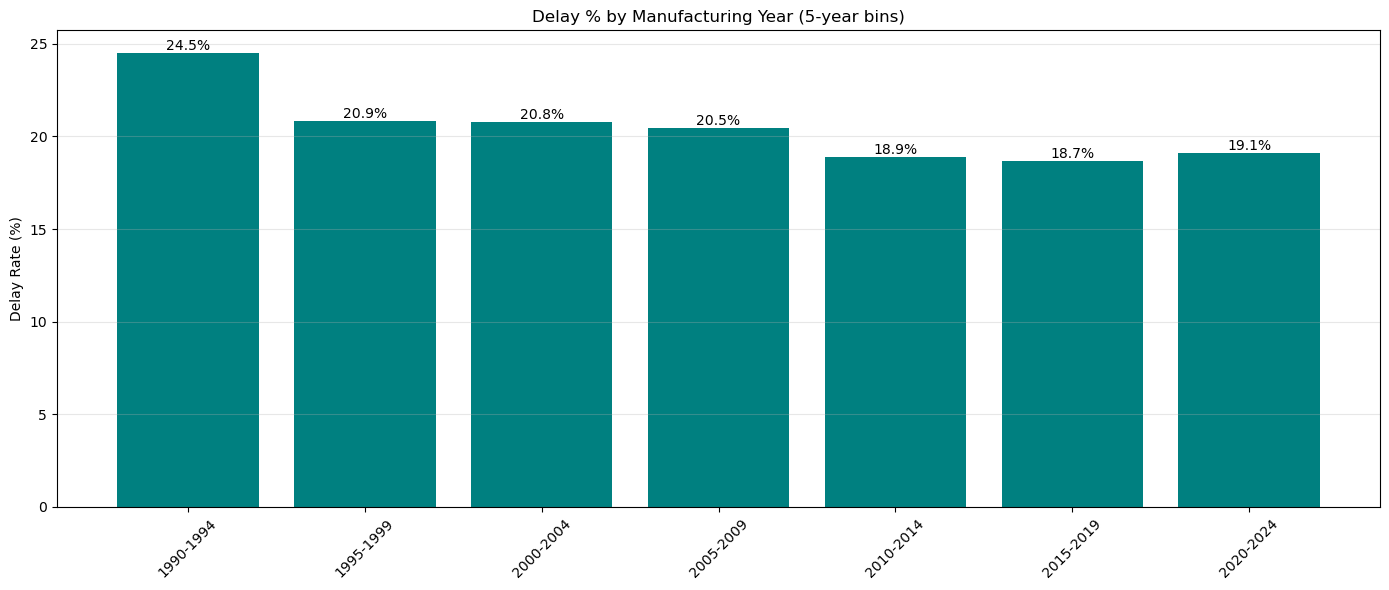

In [22]:
df["aircraft_year_mfr"] = pd.to_numeric(df["aircraft_year_mfr"], errors="coerce")

min_year = int(df["aircraft_year_mfr"].min())
max_year = int(df["aircraft_year_mfr"].max())
bins = list(range(min_year - (min_year % 5), max_year + 6, 5))
labels = [f"{b}-{b+4}" for b in bins[:-1]]

df["mfg_group"] = pd.cut(df["aircraft_year_mfr"], bins=bins, labels=labels)

delay_by_group = df.groupby("mfg_group")["DELAYED"].mean() * 100
delay_by_group = delay_by_group.dropna()

plt.figure(figsize=(14,6))
bars = plt.bar(delay_by_group.index.astype(str), delay_by_group.values, color="teal")
for bar in bars:
    y = bar.get_height()
    plt.text(bar.get_x()+bar.get_width()/2, y, f"{y:.1f}%", 
             ha='center', va='bottom')
plt.xticks(rotation=45)
plt.title("Delay % by Manufacturing Year (5-year bins)")
plt.ylabel("Delay Rate (%)")
plt.grid(axis="y", alpha=0.3)
plt.tight_layout()
plt.show()


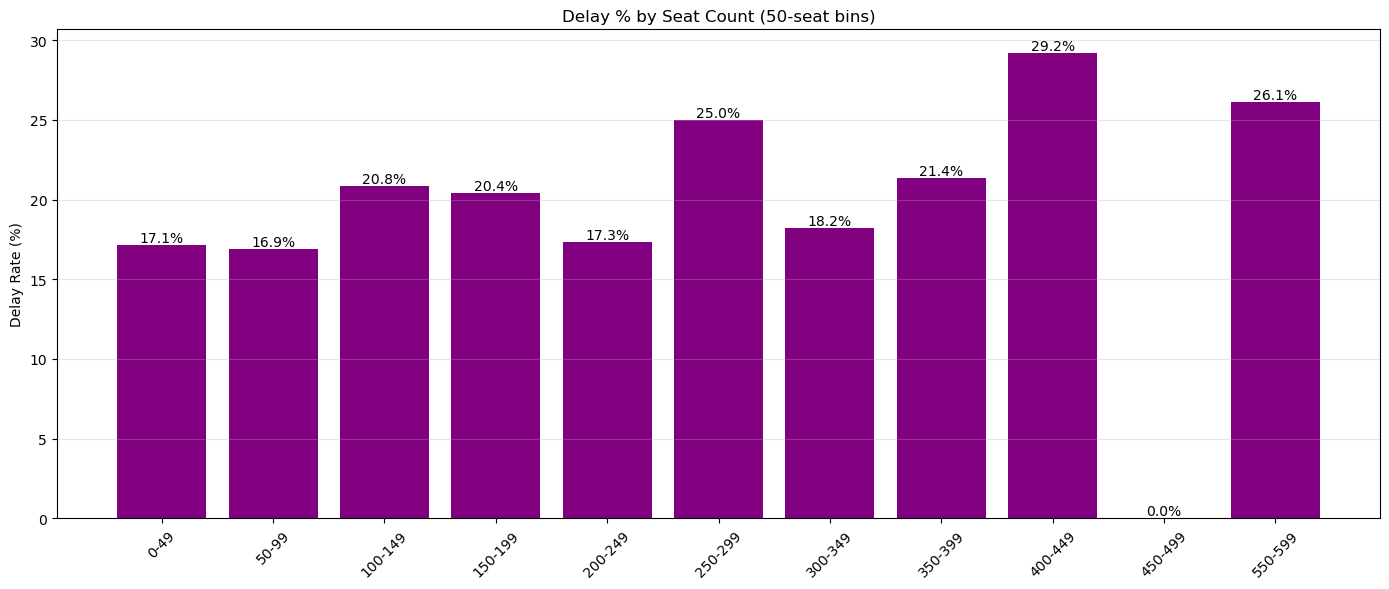

In [23]:
df["aircraft_num_seats"] = pd.to_numeric(df["aircraft_num_seats"], errors="coerce")

min_seats = int(df["aircraft_num_seats"].min())
max_seats = int(df["aircraft_num_seats"].max())
bins = list(range((min_seats//50)*50, (max_seats//50+1)*50 + 1, 50))
labels = [f"{b}-{b+49}" for b in bins[:-1]]

df["seat_group"] = pd.cut(df["aircraft_num_seats"], bins=bins, labels=labels)

delay_by_seats = df.groupby("seat_group")["DELAYED"].mean() * 100
delay_by_seats = delay_by_seats.dropna()

plt.figure(figsize=(14,6))
bars = plt.bar(delay_by_seats.index.astype(str), delay_by_seats.values, color="purple")
for bar in bars:
    y = bar.get_height()
    plt.text(bar.get_x()+bar.get_width()/2, y, f"{y:.1f}%", 
             ha='center', va='bottom')
plt.xticks(rotation=45)
plt.title("Delay % by Seat Count (50-seat bins)")
plt.ylabel("Delay Rate (%)")
plt.grid(axis="y", alpha=0.3)
plt.tight_layout()
plt.show()

In [24]:
df = df.drop(columns=["mfg_group","seat_group"])
print(df.head())

   YEAR  MONTH  DAY_OF_MONTH  DAY_OF_WEEK OP_UNIQUE_CARRIER TAIL_NUM  \
0  2023      4             1            6                AA   N103NN   
1  2023      4             1            6                AA   N108NN   
2  2023      4             1            6                AA   N112AN   
3  2023      4             1            6                AA   N121AN   
4  2023      4             1            6                AA   N122NN   

   CRS_DEP_TIME  DEP_DELAY_NEW  location_id  temp_f  ...  wind_gust_10m_mph  \
0          1045            0.0            0    51.4  ...                4.9   
1          2225            0.0            0    50.3  ...                9.6   
2           600            0.0            0    47.0  ...                7.6   
3          1332           73.0            0    54.3  ...                7.2   
4           600            0.0            0    47.0  ...                7.6   

   is_day  aircraft_mfr        aircraft_model  aircraft_num_seats  \
0       1        AIRBUS

In [25]:
df.to_csv("final_flight_dataset.csv", index=False)

Final feature matrix shape: (464050, 32)
Train size: (324835, 32)
Test size : (139215, 32)

Training Random Forest (200 trees, depth=12, one-hot encoded)...
 → Training done.

=== Test set performance ===
Accuracy: 0.6560
F1 Score: 0.4290

Classification report:
              precision    recall  f1-score   support

           0     0.8881    0.6548    0.7538    111983
           1     0.3176    0.6607    0.4290     27232

    accuracy                         0.6560    139215
   macro avg     0.6029    0.6578    0.5914    139215
weighted avg     0.7765    0.6560    0.6903    139215



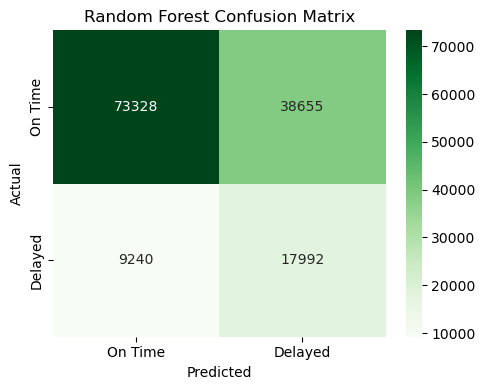


Top 20 feature importances:
CRS_DEP_TIME                   0.3340
wind_speed_100m_mph            0.0938
DAY_OF_YEAR                    0.0869
wind_gust_10m_mph              0.0719
temp_f                         0.0551
cloud_cover_low_pct            0.0399
MONTH                          0.0376
aircraft_num_seats             0.0369
DAY_OF_WEEK                    0.0311
precip_in                      0.0304
aircraft_year_mfr              0.0293
airport_SFO                    0.0233
airport_SJC                    0.0182
CARRIER_NAME_Southwest Airlines Co. 0.0173
CARRIER_NAME_Frontier Airlines Inc. 0.0151
is_day                         0.0118
aircraft_mfr_EMBRAER           0.0104
CARRIER_NAME_United Air Lines Inc. 0.0087
CARRIER_NAME_Delta Air Lines Inc. 0.0077
airport_OAK                    0.0068


In [26]:
#Random forest
import numpy as np
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (
    accuracy_score, f1_score, classification_report, confusion_matrix
)
import seaborn as sns
import matplotlib.pyplot as plt


feature_cols = [
    "MONTH",
    "DAY_OF_WEEK",
    "DAY_OF_YEAR",
    "CRS_DEP_TIME",
    "temp_f",
    "cloud_cover_low_pct",
    "precip_in",
    "wind_speed_100m_mph",
    "wind_gust_10m_mph",
    "is_day",
    "aircraft_num_seats",
    "aircraft_year_mfr",
    "airport",
    "CARRIER_NAME",
    "aircraft_mfr",
]

cat_cols = ["airport", "CARRIER_NAME", "aircraft_mfr"]
X = df[feature_cols].copy()


X = pd.get_dummies(X, columns=cat_cols, drop_first=False)
y = df["DELAYED"].to_numpy()

print("Final feature matrix shape:", X.shape)

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.3,          # 70/30 split
    random_state=123,
    stratify=y,
)

print("Train size:", X_train.shape)
print("Test size :", X_test.shape)

rf = RandomForestClassifier(
    n_estimators=200,
    max_depth=12,
    class_weight="balanced",
    n_jobs=-1,
    random_state=789,
    bootstrap=True,
)

print("\nTraining Random Forest (200 trees, depth=12, one-hot encoded)...")
rf.fit(X_train, y_train)
print(" → Training done.")

# Predictions
y_pred = rf.predict(X_test)

# Metrics
acc = accuracy_score(y_test, y_pred)
f1  = f1_score(y_test, y_pred)

print("\n=== Test set performance ===")
print(f"Accuracy: {acc:.4f}")
print(f"F1 Score: {f1:.4f}")
print("\nClassification report:")
print(classification_report(y_test, y_pred, digits=4))

# Confusion matrix
cm = confusion_matrix(y_test, y_pred)
plt.figure(figsize=(5, 4))
sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Greens",
    xticklabels=["On Time", "Delayed"],
    yticklabels=["On Time", "Delayed"],
)
plt.title("Random Forest Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.tight_layout()
plt.show()

# Optional: feature importances
importances = rf.feature_importances_
fi = sorted(zip(X.columns, importances), key=lambda x: x[1], reverse=True)

print("\nTop 20 feature importances:")
for name, val in fi[:20]:
    print(f"{name:30s} {val:.4f}")


Checking whether there is an H2O instance running at http://localhost:54321..... not found.
Attempting to start a local H2O server...
; Java HotSpot(TM) 64-Bit Server VM (build 25.291-b10, mixed mode)
  Starting server from C:\Users\herbe\anaconda3\Lib\site-packages\h2o\backend\bin\h2o.jar
  Ice root: C:\Users\herbe\AppData\Local\Temp\tmpbumsf0_a
  JVM stdout: C:\Users\herbe\AppData\Local\Temp\tmpbumsf0_a\h2o_herbe_started_from_python.out
  JVM stderr: C:\Users\herbe\AppData\Local\Temp\tmpbumsf0_a\h2o_herbe_started_from_python.err
  Server is running at http://127.0.0.1:54321
Connecting to H2O server at http://127.0.0.1:54321 ... successful.


H2O_cluster_uptime:,02 secs
H2O_cluster_timezone:,America/Los_Angeles
H2O_data_parsing_timezone:,UTC
H2O_cluster_version:,3.46.0.9
H2O_cluster_version_age:,13 days
H2O_cluster_name:,H2O_from_python_herbe_q40m2t
H2O_cluster_total_nodes:,1
H2O_cluster_free_memory:,7.077 Gb
H2O_cluster_total_cores:,16
H2O_cluster_allowed_cores:,16
H2O_cluster_status:,"locked, healthy"


Parse progress: |████████████████████████████████████████████████████████████████| (done) 100%
Train rows: 325006
Valid rows: 69515
Test rows : 69530
gbm Model Build progress: |██████████████████████████████████████████████████████| (done) 100%

Trained GBM in 25.96 seconds.
Built 110 trees (up to 500 requested).

=== Validation performance ===
ModelMetricsBinomial: gbm
** Reported on test data. **

MSE: 0.14212429528076395
RMSE: 0.3769937602676786
LogLoss: 0.462998789829338
Mean Per-Class Error: 0.33830625832239847
AUC: 0.7228139833300812
AUCPR: 0.4084426346649726
Gini: 0.44562796666016236

Confusion Matrix (Act/Pred) for max f1 @ threshold = 0.15612197504297606
       0      1      Error    Rate
-----  -----  -----  -------  -----------------
0      40907  15050  0.269    (15050.0/55957.0)
1      5527   8031   0.4077   (5527.0/13558.0)
Total  46434  23081  0.296    (20577.0/69515.0)

Maximum Metrics: Maximum metrics at their respective thresholds
metric                       threshol

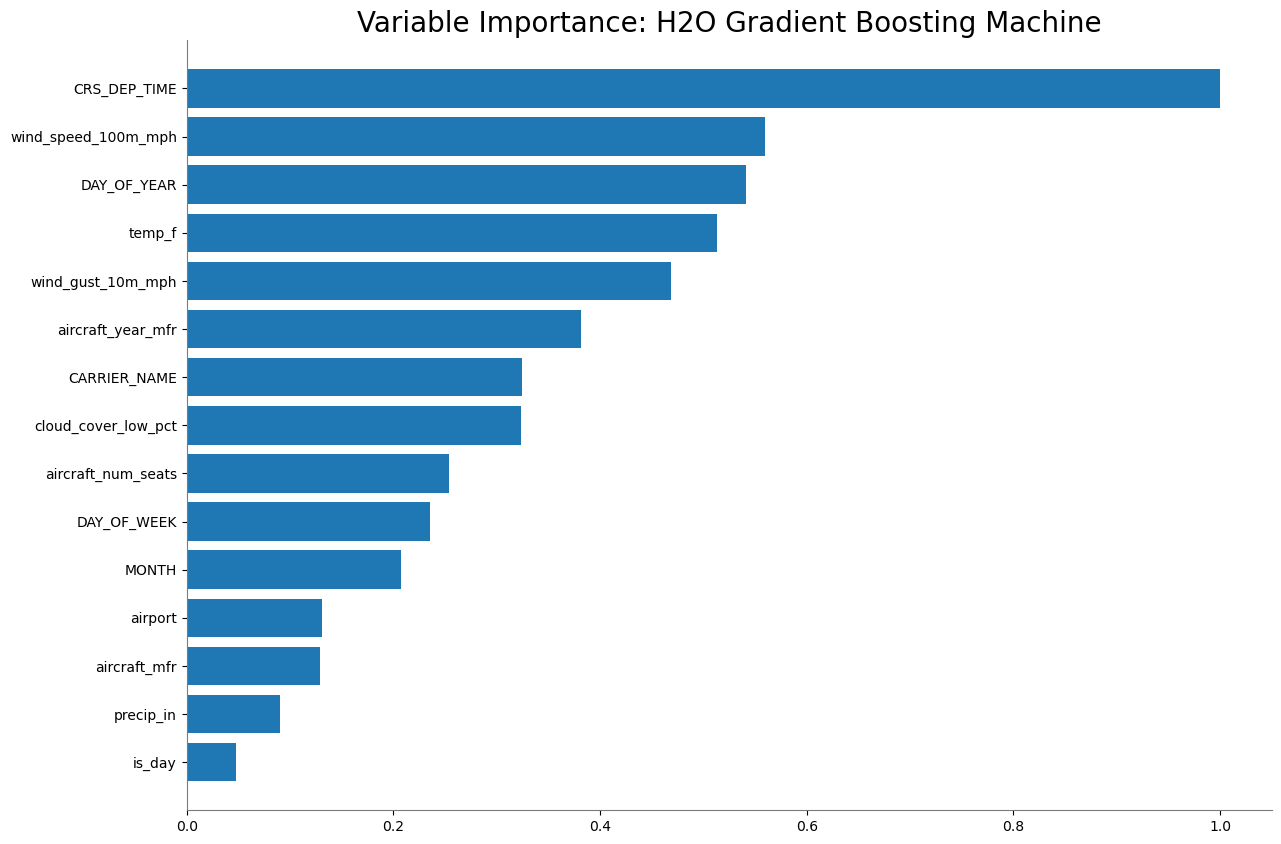

<Figure size 640x480 with 0 Axes>

In [27]:
#GBM Attempt
import h2o
from h2o.estimators import H2OGradientBoostingEstimator
import time

h2o.init() 

hf = h2o.H2OFrame(df)

hf["DELAYED"] = hf["DELAYED"].asfactor()


feature_cols = [
    "MONTH",
    "DAY_OF_WEEK",
    "DAY_OF_YEAR",
    "CRS_DEP_TIME",
    "temp_f",
    "cloud_cover_low_pct",
    "precip_in",
    "wind_speed_100m_mph",
    "wind_gust_10m_mph",
    "is_day",
    "aircraft_num_seats",
    "aircraft_year_mfr",
    "airport",         
    "CARRIER_NAME",
    "aircraft_mfr",
]

target_col = "DELAYED"

train, valid, test = hf.split_frame(
    ratios=[0.7, 0.15],
    seed=42
)

print("Train rows:", train.nrows)
print("Valid rows:", valid.nrows)
print("Test rows :", test.nrows)


gbm = H2OGradientBoostingEstimator(
    ntrees=500,                  
    max_depth=17,
    sample_rate=0.91,
    col_sample_rate=0.33,
    col_sample_rate_change_per_level=0.95,
    min_rows=16,
    nbins=512,
    nbins_cats=64,
    min_split_improvement=0.0,
    distribution="bernoulli",
    balance_classes=True,
    stopping_rounds=5,
    stopping_metric="AUC",     
    stopping_tolerance=1e-4,
    score_tree_interval=10,   
    seed=42
)

start = time.perf_counter()
gbm.train(
    x=feature_cols,
    y=target_col,
    training_frame=train,
    validation_frame=valid,
)
end = time.perf_counter()

elapsed = end - start
print(f"\nTrained GBM in {elapsed:.2f} seconds.")
print(f"Built {gbm.params['ntrees']['actual']} trees "
      f"(up to {gbm.params['ntrees']['input']} requested).")

print("\n=== Validation performance ===")
perf_valid = gbm.model_performance(valid)
print(perf_valid)

print("\n=== Test performance ===")
perf_test = gbm.model_performance(test)
print(perf_test)
try:
    print("\nValidation AUC:", perf_valid.auc())
    print("Validation F1 (default threshold):", perf_valid.F1()[0][1])
except:
    pass

gbm.varimp_plot(num_of_features=20)
